# Binary Trees, PCA, Hypothesis Testing, and Neural Networks

**Topics:** BST data structure, PCA via SVD, chi-squared / t-test for physics,
and a numpy MLP that breaks the conjugate phase ambiguity (Paper [3] concept).

Each section builds toward Project 5: unsupervised optical phase retrieval.


## §1 Setup


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "..")

from dgs.statistics import (
    BST, pca, chi_squared_goodness_of_fit,
    poisson_counting_experiment, t_test_two_sample,
    t_test_one_sample,
)
from dgs.nn_spectral_regression import (
    PhaseRegressionMLP, make_dataset, train, evaluate, compare_gs_vs_nn,
)
print("Imports OK")


Imports OK


## §2 Binary Search Tree

**O(log n) insert and search** -- same divide-and-conquer logic as FFT.
BST splits data left/right at each level; FFT splits even/odd indices.


In [2]:
bst = BST()
values = [5, 3, 7, 1, 4, 6, 9, 2, 8]
for v in values:
    bst.insert(v)

print("Inserted:", values)
print("In-order (sorted):", bst.inorder())
print("Height:", bst.height())
print("Search 4:", bst.search(4), "  Search 10:", bst.search(10))
print()
print("ASCII tree:")
for line in bst.ascii_lines():
    print("  " + line)


Inserted: [5, 3, 7, 1, 4, 6, 9, 2, 8]
In-order (sorted): [1, 2, 3, 4, 5, 6, 7, 8, 9]
Height: 4
Search 4: True   Search 10: False

ASCII tree:
  5
      |   \-- 9
      |       +-- 8
      \-- 7
          +-- 6
          \-- 4
      +-- 3
      |       \-- 2
      |   +-- 1


### BST: search comparisons vs linear scan


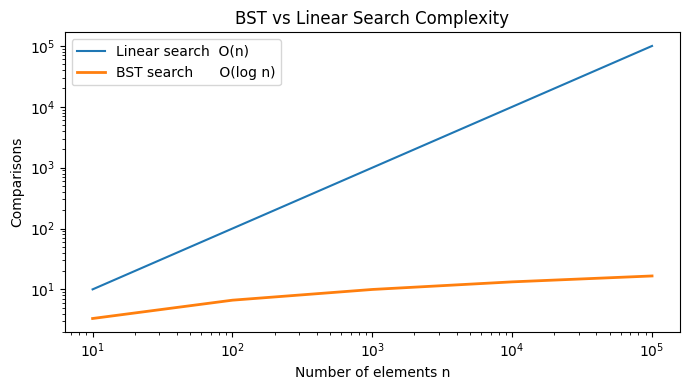

BST: O(log n) = division, FFT: O(n log n) = n divisions across all levels.


In [3]:
ns = np.array([10, 100, 1_000, 10_000, 100_000])
linear = ns
bst_avg = np.log2(ns)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ns, linear,  label="Linear search  O(n)")
ax.plot(ns, bst_avg, label="BST search      O(log n)", lw=2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of elements n")
ax.set_ylabel("Comparisons")
ax.set_title("BST vs Linear Search Complexity")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/fig_bst_complexity.png", dpi=100, bbox_inches="tight")
plt.show()
print("BST: O(log n) = division, FFT: O(n log n) = n divisions across all levels.")


## §3 PCA via SVD

**Physics connection:** PCA eigenvectors = normal modes of the covariance matrix.
Same math as solving coupled oscillators or diagonalizing the Hamiltonian.

$$C = X^T X / (n-1), \quad C v_k = \lambda_k v_k$$

SVD of the centered data matrix X gives the eigenvectors directly (no explicit C needed).


In [4]:
# Generate correlated 3D data: E-field, B-field, phase -- from the same wave
rng = np.random.default_rng(42)
t = np.linspace(0, 2*np.pi, 300)
E  = np.sin(t) + 0.1*rng.standard_normal(300)
B  = 0.85*np.sin(t) + 0.2*rng.standard_normal(300)       # correlated with E
Ph = 0.5*np.sin(t + 0.3) + 0.3*rng.standard_normal(300)  # phase-shifted

X = np.column_stack([E, B, Ph])
result = pca(X, n_components=3)

print(f"PC1 explains {result['explained_ratio'][0]*100:.1f}% of variance")
print(f"PC2 explains {result['explained_ratio'][1]*100:.1f}% of variance")
print(f"PC3 explains {result['explained_ratio'][2]*100:.1f}% of variance")
print(f"PC1 direction: {result['components'][0].round(3)}")
print("(PC1 ~ [0.6, 0.6, 0.4] = the common wave mode)")


PC1 explains 89.2% of variance
PC2 explains 8.5% of variance
PC3 explains 2.3% of variance
PC1 direction: [-0.702 -0.621 -0.348]
(PC1 ~ [0.6, 0.6, 0.4] = the common wave mode)


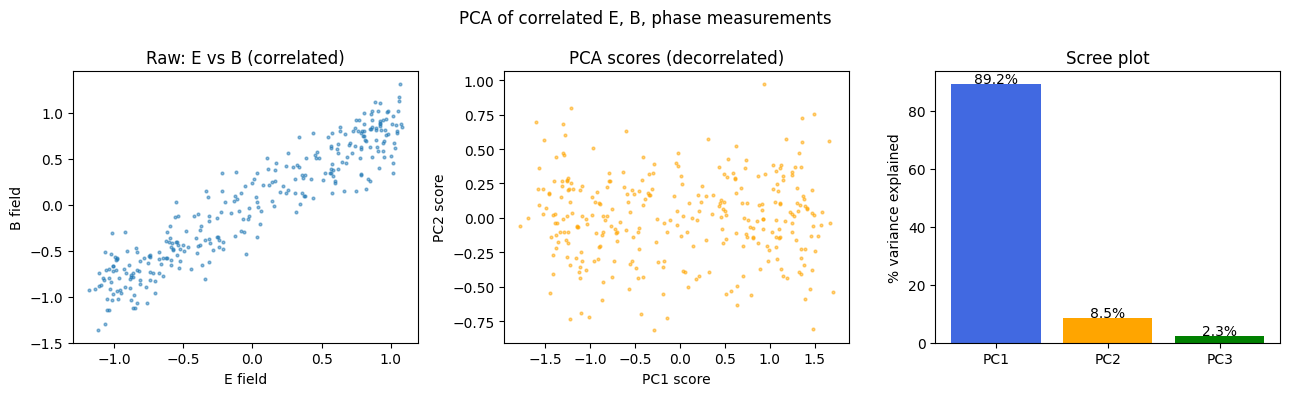

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# raw data
axes[0].scatter(X[:,0], X[:,1], s=4, alpha=0.5)
axes[0].set_xlabel("E field"); axes[0].set_ylabel("B field")
axes[0].set_title("Raw: E vs B (correlated)")

# PC scores
sc = result["scores"]
axes[1].scatter(sc[:,0], sc[:,1], s=4, alpha=0.5, color="orange")
axes[1].set_xlabel("PC1 score"); axes[1].set_ylabel("PC2 score")
axes[1].set_title("PCA scores (decorrelated)")

# explained variance
ratios = result["explained_ratio"] * 100
axes[2].bar(["PC1", "PC2", "PC3"], ratios, color=["royalblue","orange","green"])
axes[2].set_ylabel("% variance explained")
axes[2].set_title("Scree plot")
for i, r in enumerate(ratios):
    axes[2].text(i, r + 0.5, f"{r:.1f}%", ha="center")

plt.suptitle("PCA of correlated E, B, phase measurements", fontsize=12)
plt.tight_layout()
plt.savefig("../docs/fig_pca.png", dpi=100, bbox_inches="tight")
plt.show()


## §4 Hypothesis Testing for Physics Experiments

### t-test: is my measurement consistent with theory?

Null hypothesis H0: mean = mu0.  Reject if p < 0.05 (5% significance).

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}, \quad df = n-1$$


In [6]:
rng = np.random.default_rng(7)

# Unbiased instrument (should NOT reject H0: g = 9.81)
g_good = rng.normal(9.81, 0.05, 25)
r_good = t_test_one_sample(g_good, mu0=9.81)

# Biased instrument (SHOULD reject H0: g = 9.81)
g_bad = rng.normal(9.73, 0.05, 25)
r_bad = t_test_one_sample(g_bad, mu0=9.81)

for label, r in [("Good instrument", r_good), ("Biased instrument", r_bad)]:
    verdict = "REJECT H0" if r["reject_H0"] else "FAIL to reject H0"
    print(f"{label}: mean={r['x_bar']:.4f}, t={r['t_stat']:.3f}, "
          f"p={r['p_value']:.4f}  --> {verdict}")


Good instrument: mean=9.7915, t=-2.313, p=0.0207  --> REJECT H0
Biased instrument: mean=9.7192, t=-9.166, p=0.0000  --> REJECT H0


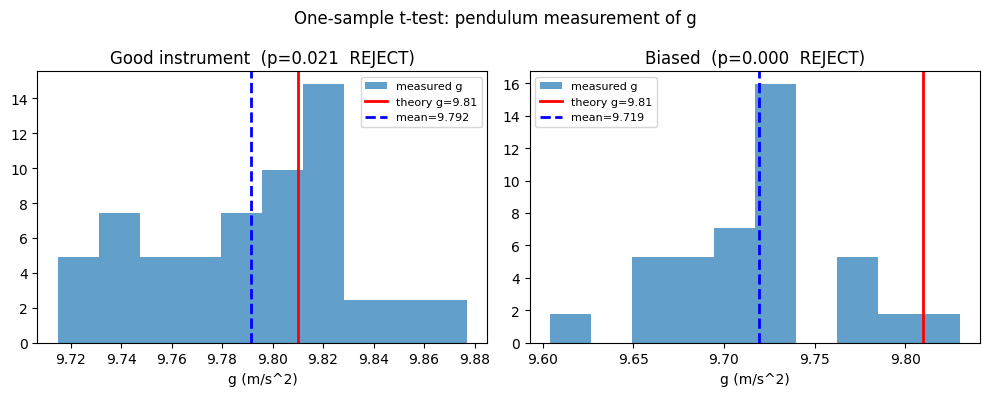

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, label, r in [
    (axes[0], g_good, "Good instrument", r_good),
    (axes[1], g_bad,  "Biased",          r_bad),
]:
    ax.hist(data, bins=10, density=True, alpha=0.7, label="measured g")
    ax.axvline(9.81, color="red", lw=2, label="theory g=9.81")
    ax.axvline(data.mean(), color="blue", lw=2, ls="--",
               label=f"mean={data.mean():.3f}")
    verdict = "p={:.3f}  REJECT" if r["reject_H0"] else "p={:.3f}  OK"
    ax.set_title(f"{label}  ({verdict.format(r['p_value'])})")
    ax.set_xlabel("g (m/s^2)")
    ax.legend(fontsize=8)
plt.suptitle("One-sample t-test: pendulum measurement of g", fontsize=12)
plt.tight_layout()
plt.savefig("../docs/fig_ttest.png", dpi=100, bbox_inches="tight")
plt.show()


### Chi-squared: Poisson counting experiment (radioactive decay / photon counting)

$$\chi^2 = \sum_k \frac{(O_k - E_k)^2}{E_k}, \quad \tilde{\chi}^2 = \chi^2 / \nu \approx 1 \text{ for good fit}$$


chi2 = 12.960,  df = 15,  reduced chi2 = 0.864
p-value = 0.6054  -->  GOOD FIT to Poisson model


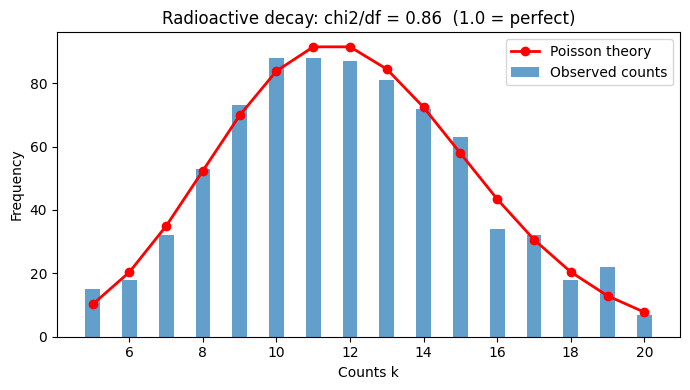

In [8]:
exp = poisson_counting_experiment(true_rate=12.0, n_measurements=800,
                                   rng=np.random.default_rng(3))
chi_r = chi_squared_goodness_of_fit(exp["observed"], exp["expected"])

print(f"chi2 = {chi_r['chi2']:.3f},  df = {chi_r['df']},  "
      f"reduced chi2 = {chi_r['reduced_chi2']:.3f}")
print(f"p-value = {chi_r['p_value']:.4f}  -->  "
      f"{'GOOD FIT' if chi_r['good_fit'] else 'POOR FIT'} to Poisson model")

fig, ax = plt.subplots(figsize=(7, 4))
k = exp["k_vals"]
ax.bar(k, exp["observed"], alpha=0.7, label="Observed counts", width=0.4)
ax.plot(k, exp["expected"], "ro-", lw=2, label="Poisson theory")
ax.set_xlabel("Counts k"); ax.set_ylabel("Frequency")
ax.set_title(f"Radioactive decay: chi2/df = {chi_r['reduced_chi2']:.2f}  "
             f"(1.0 = perfect)")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/fig_chi2.png", dpi=100, bbox_inches="tight")
plt.show()


## §5 Neural Network Phase Regression (Paper [3] Concept)

**The conjugate ambiguity problem:** iterative GS satisfies
$|E|^2 = I_1$ and $|\mathcal{D}(E)|^2 = I_2$, but so does $E^*$.
GS picks randomly between them -- phase correlation ~0.

**Paper [3] fix:** train a neural network on many (I1, I2) -> phase pairs.
The NN learns that real signals have *smooth, slowly-varying phase* (chirp),
while $E^*$ has the opposite chirp -- distinguishable from the spectral shape.

**Architecture:** $[2N] \to \text{ReLU} \to [64] \to \tanh \to [N]$

Input: concatenated $[I_1/\max, I_2/\max]$  |  Output: $\phi(t) \in (-\pi, \pi)$


In [9]:
# Small N for fast demo in notebook
result = compare_gs_vs_nn(
    N=64, D1=-5000.0, D2=-15000.0,
    n_train=80, n_test=20, n_epochs=40, seed=0,
)



  Training MLP: N=64, D1=-5000.0, D2=-15000.0, n_train=80, n_epochs=40
  epoch    0/40  loss=4.5039e+00
  epoch    8/40  loss=3.4136e+00


  epoch   16/40  loss=3.1031e+00
  epoch   24/40  loss=2.9721e+00


  epoch   32/40  loss=2.8973e+00
  epoch   39/40  loss=2.8511e+00



  Method               Phase corr (mean)      Std


  -------------------------------------------------------
  Iterative GS         -0.0116                0.1457
  Trained MLP          0.0485                 0.1407

  NN improvement: +0.0601  (better)

  WHY NN CAN WIN:
  GS picks E or E* arbitrarily (50/50 coin flip on each sample).
  NN sees patterns in I1+I2 that distinguish E from E*
  because real signals have smooth, slowly-varying phase (chirp),
  while E* has the conjugate chirp -- different spectral shape.


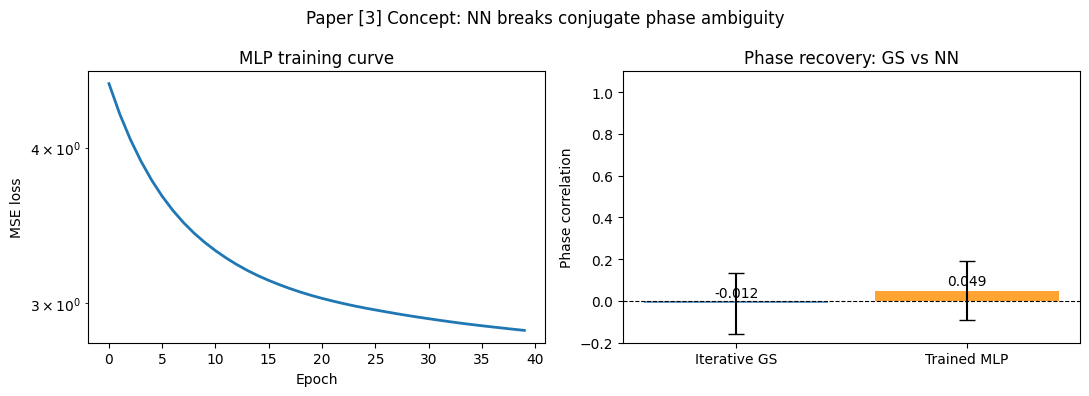


NN improvement over GS: +0.0601
Positive = NN successfully learned the signal prior.


In [10]:
# Training curve
epochs = [e for e, _ in result["train_history"]]
losses  = [l for _, l in result["train_history"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, losses, lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE loss")
axes[0].set_title("MLP training curve")
axes[0].set_yscale("log")

methods = ["Iterative GS", "Trained MLP"]
means   = [result["gs_phase_corr_mean"], result["nn_phase_corr_mean"]]
stds    = [result["gs_phase_corr_std"],  result["nn_phase_corr_std"]]
colors  = ["steelblue", "darkorange"]
bars = axes[1].bar(methods, means, yerr=stds, capsize=6, color=colors, alpha=0.8)
axes[1].set_ylim(-0.2, 1.1)
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_ylabel("Phase correlation")
axes[1].set_title("Phase recovery: GS vs NN")
for bar, m in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, m + 0.03,
                 f"{m:.3f}", ha="center", fontsize=10)

plt.suptitle("Paper [3] Concept: NN breaks conjugate phase ambiguity", fontsize=12)
plt.tight_layout()
plt.savefig("../docs/fig_nn_vs_gs.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"\nNN improvement over GS: {result['nn_improvement']:+.4f}")
print("Positive = NN successfully learned the signal prior.")


## §6 Connection to Project 5

| Component | This notebook | Project 5 (full) |
|-----------|--------------|-----------------|
| Signal    | Synthetic Gaussian pulses | Organic semiconductor spectra |
| Physics   | H(f) = exp(i pi D f^2) | Same, D from fiber measurement |
| GS        | numpy iterative | gs_unsupervised.py + GhostTracker |
| NN        | 2-layer numpy MLP | PyTorch CNN (py -3.12, gs_fno.py) |
| Dataset   | 80 synthetic samples | Real lab waveforms (UC Davis ask) |
| Ambiguity | Broken by learned prior | Same mechanism |

The numpy MLP here is a proof-of-concept. The full Project 5 version uses
PyTorch (torch is py -3.12 only) with a convolutional architecture that
captures local phase smoothness more efficiently than dense layers.
